# Filtraggio lineare

Il filtraggio lineare è un tipo di filtraggio che consiste nell'applicare una maschera (kernel) e sostituire i pixel sottostanti con la media pesata con i coefficienti della maschera. Nell'ambito della visione artificiale questa operazione viene effettuata per operazioni di *blurring* o *smoothing*


I filtri di *smoothing* sono usati per sfocare l’immagine e ridurre il rumore. Un esempio classico è il filtro di media, in cui ogni pixel viene sostituito con la media dei valori presenti nel suo intorno.


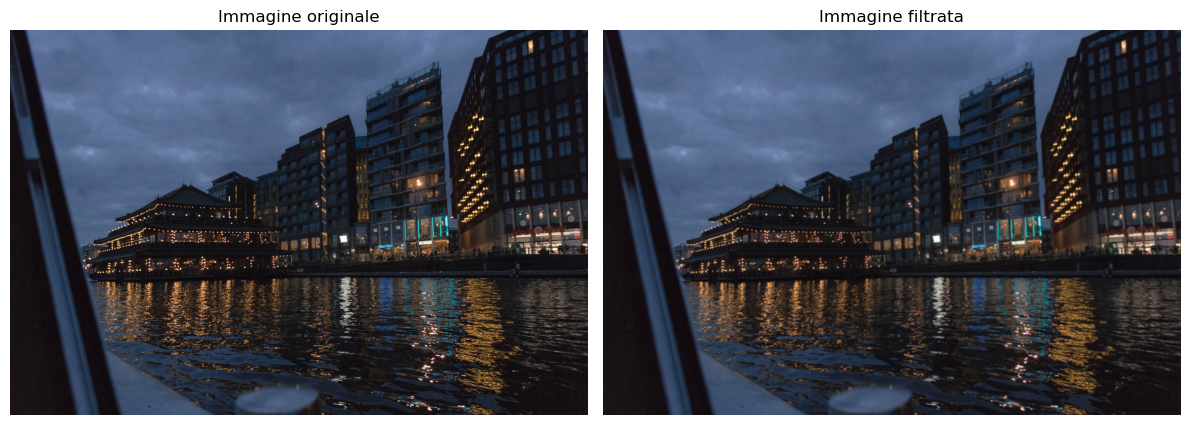

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

im_low = cv2.imread("low_contrast.jpg")

kernel = (1/121) * np.ones((11,11), np.float32)

#Applicazione del filtro lineare all'immagine
avg = cv2.filter2D(src=im_low, ddepth=-1, kernel=kernel)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,6))

#OpenCV carica in BGR, Matlpotlib in RGB 
ax1.imshow(cv2.cvtColor(im_low, cv2.COLOR_BGR2RGB))
ax1.set_title("Immagine originale")
ax1.axis('off')

ax2.imshow(cv2.cvtColor(avg, cv2.COLOR_BGR2RGB))
ax2.set_title("Immagine filtrata")
ax2.axis('off')

plt.tight_layout()
plt.show()

In questo caso `cv2.filter2D` implementa una convoluzione, internamente il kernel `uniforme` ruota di 180 gradi, essendo però simmetrico non cambia nulla e dunque si parla di operazione di *blurring*.

La **correlazione** misura quanto una maschera somiglia a una certa regione dell’immagine. Per questo motivo è molto usata nel **template matching**: il valore della correlazione è alto quando il template coincide bene con una porzione dell’immagine.

La **convoluzione**, invece, combina due segnali per produrne uno nuovo. In termini di sistemi lineari, descrive l’effetto di un filtro sul segnale di input. Per questo è usata per operazioni come smoothing, sharpening e rilevamento dei bordi.

Sia la correlazione sia la convoluzione sono operatori **lineari** e **shift-invariant**, cioè rispettano due proprietà fondamentali.

### Smoothing solo sulla luminanza

Nel caso in cui si voglia applicare il filtro solo alla componente di luminanza nello spazio YCbCr sarebbe una soluzione migliore quando si vuole sfocare o regolarizzare l'intensità senza modificare le componenti cromatiche. 

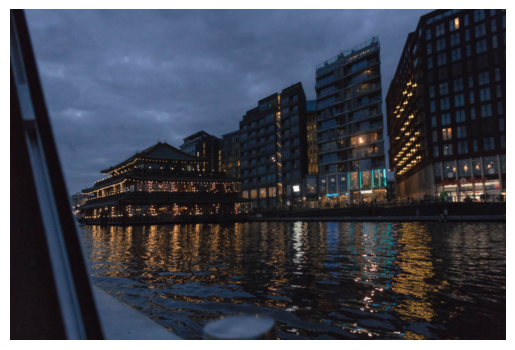

In [6]:
import cv2
import numpy as np

im_low = cv2.imread("low_contrast.jpg")

ycrcb = cv2.cvtColor(im_low, cv2.COLOR_BGR2YCrCb)

# Estrazione solo del canale Y, solo luminanza 

y_channel = ycrcb[:,:,0]

# Kernel medio 11x11

kernel = (1/121) * np.ones((11,11), np.float32)

# Applicazione del filtro solo sul canale della luminanza

ycrcb[:,:,0] = cv2.filter2D(src=y_channel, ddepth=-1, kernel=kernel)

# Riconversione in RGB per mostrarla con MATPLOT

plt.imshow(cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB))
plt.axis('off')
plt.show()


In questo secondo caso l’informazione cromatica non viene filtrata direttamente. 
Il filtro agisce sul canale *Y*, quindi modifica principalmente la struttura luminosa dell’immagine. L’effetto è diverso dal filtraggio diretto sui tre canali, perché la crominanza viene preservata meglio.

## Padding

Durante il filtraggio spaziale il kernel deve essere centrato su ogni pixel dell'immagine. Il problema nasce ai bordi: quando un kernel è centrato su un pixel vicino al bordo una parte della maschera cade fuori dall'immagine. 

Senza **padding** il filtro può essere applicato solo nelle posizioni in cui il kernel ricade esattamente all'interno dell'immagine. Di conseguenza l'immagine in output risulta più piccola di quella originale. 

Per ottenere un'immagine filtrata della stessa dimensione dell'input si utilizza il **padding**, cioè si estende artificialmente l'immagine aggiungendo pixel ai bordi.

## Filtro Gaussiano

Una modalità di *smoothing* più raffinata è ottenuta tramite il **filtro gaussiano**. Invece di assegnare lo stesso peso a tutti i pixel dell'intorno, il filtro gaussiano assegna più peso ai pixel vicini al centro della maschera e un peso minore a quelli vicini al bordo.

I coefficienti vengono normalizzati in modo che la somma totale dei pesi sia pari a 1. Questo evita di introdurre una variazione globale indesiderata nella luminosità media dell’immagine.

Rispetto al filtro medio, il filtro gaussiano tende a produrre una sfocatura più naturale, perché il pixel centrale e quelli vicini hanno maggiore influenza rispetto ai pixel più lontani.

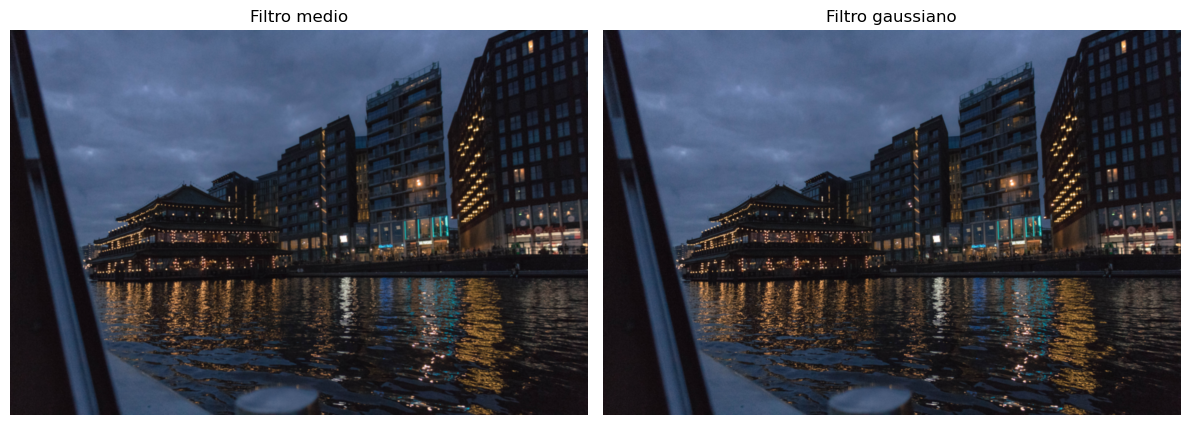

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

im_low = cv2.imread("low_contrast.jpg")

kernel = (1/121) * np.ones((11,11), np.float32)

# Filtro medio applicato tramite filter2D
avg = cv2.filter2D(src=im_low, ddepth=-1, kernel=kernel)

# Filtro medio applicato tramite blur

blur = cv2.blur(im_low, (11,11))

# Filtro gaussiano con kernel 11x11 e sigma 5
gaussian_blur = cv2.GaussianBlur(im_low, (11,11), 5)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,6))

ax1.set_title("Filtro medio")
ax1.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
ax1.axis('off')

ax2.set_title("Filtro gaussiano")
ax2.imshow(cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB))
ax2.axis('off')

plt.tight_layout()
plt.show()




il parametro *sigma* nella funzione `cv2.GaussianBlur` rappresenta la **deviazione standard** della distribuzione e ne determina l'intensità dello sfocamento.

